# OnPoint Demand-Response — End-to-End Pipeline

From the trained **LSTM v5** forecaster to deployable business insights, in one file.

| Stage | What happens | Output |
|---|---|---|
| **1. LSTM residuals** | Load `lstm_v5_best.pt`, predict the counterfactual demand on the test split, take residual = actual − predicted | per-row residual table (cached) |
| **2. Signal-specific peaks** | Derive each price signal's own peak-hour window from `price_signals.csv` | `peak_hours_by_signal` |
| **3. Five statistical fixes** | DiD ▸ Jensen recenter ▸ one-sided z + BH-FDR ▸ effect-size gate ▸ placebo FPR | `events_v2_signal.csv` |
| **4. Responder tiers** | flag_rate → Reliable / Occasional / Non-responder | tiers |
| **5. Targeting model** | predict reliability from 12 months of meter history | RF + lift/calibration |
| **6. Insights** | dose-response, signal bias, habituation, load-shed capacity | tables |

**Four review improvements are marked `[Cx]` inline:**
- **[C1]** tier labels are signal-biased → normalise flag_rate by signal difficulty + EB-shrink before tiering
- **[C2]** "25% never respond" → verify each non-responder actually *had the power* to be detected
- **[C3]** report top-decile lift + calibration (the deployment metric), and re-fit on de-biased labels
- **[C4]** habituation: control for signal escalation and temperature before claiming "learning"

> Paths assume the notebook lives in `final/` with data in `../data/`. Run cells top-to-bottom.

## 0 · Setup

In [1]:
import warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from scipy.stats import norm, chi2_contingency
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)

DATA   = Path("../data")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LSTM v5 hyperparameters — must match training
LOOKBACK, HIDDEN, NUM_LAYERS, DROPOUT, N_FEATURES, BATCH = 168, 256, 3, 0.3, 20, 512
# detection parameters
MIN_PEAK_HOURS, MIN_NON_EVENT, ALPHA_FDR, MIN_REL_DROP = 1, 100, 0.05, 0.10
RNG = np.random.default_rng(42)
RESID_CACHE = DATA / "lstm_v5_test_residuals.parquet"   # per-row residuals cached here
print("device:", DEVICE)

device: cuda


## 1 · LSTM v5 → test-set residuals

The detector needs the **per-hour residual** `actual − predicted` for every test row, which
isn't stored on disk, so we run the LSTM forward pass once and cache it. The forward pass is
the only slow step (~2–3 min on GPU); afterwards every rerun loads the parquet instantly.

The per-row table carries `From` (datetime) and `Temperature` so later stages can order
events in time and control for weather — neither was available in the old events table.

In [2]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def compute_test_residuals():
    # --- load TSA, rejoin temperature + clusters, impute event hours (kills lag-leakage) ---
    tsa = pd.read_parquet(DATA / "tsa_baseline.parquet"); tsa["ID"] = tsa["ID"].astype(str)
    parts = pd.read_csv(DATA / "participants.csv", usecols=["ID", "Region"], encoding="latin-1")
    parts["ID"] = parts["ID"].astype(str)
    tsa = tsa.merge(parts, on="ID", how="left"); tsa["Region"] = tsa["Region"].fillna("UNK")
    clu = pd.read_csv(DATA / "user_clusters_k2.csv", index_col=0); clu.index = clu.index.astype(str)
    tsa = tsa.merge(clu, left_on="ID", right_index=True, how="inner"); tsa["cluster"] = tsa["cluster"].astype(np.int8)
    hourly = pd.read_csv(DATA / "data_hourly.csv",
                         usecols=["ID", "From", "Temperature", "Temperature24", "Temperature48", "Temperature72"],
                         parse_dates=["From"]); hourly["ID"] = hourly["ID"].astype(str)
    tsa = (tsa.merge(hourly, on=["ID", "From"], how="left")
              .dropna(subset=["Temperature"]).sort_values(["ID", "From"]).reset_index(drop=True))
    non = tsa[tsa["event_flag"] == 0]
    hm = non.groupby(["ID", "Hour"], observed=True)["Demand_kWh"].mean().reset_index().rename(columns={"Demand_kWh": "hm"})
    tsa = tsa.merge(hm, on=["ID", "Hour"], how="left")
    tsa["hm"] = tsa["hm"].fillna(tsa["ID"].map(non.groupby("ID")["Demand_kWh"].mean()))
    tsa["Demand_imp"] = np.where(tsa["event_flag"] == 1, tsa["hm"].astype(np.float32), tsa["Demand_kWh"].astype(np.float32))
    tsa.drop(columns="hm", inplace=True)
    print(f"rows {len(tsa):,}  users {tsa['ID'].nunique():,}  imputed {(tsa['event_flag']==1).sum():,} event-hours")

    # --- build per-user 20-feature arrays (order MUST match training) ---
    reg = pd.get_dummies(tsa["Region"], prefix="r", drop_first=True).astype(np.float32)
    region_cols = reg.columns.tolist(); tsa = pd.concat([tsa, reg], axis=1)
    users = tsa["ID"].drop_duplicates().tolist(); u2i = {u: i for i, u in enumerate(users)}
    arrays = [None]*len(users); eflags = [None]*len(users); psig = [None]*len(users)
    horig = [None]*len(users); acts = [None]*len(users)
    mu_log = np.zeros(len(users), np.float32); sg_log = np.ones(len(users), np.float32)
    clu_u = np.zeros(len(users), np.int8)
    tcols = ["Temperature", "Temperature24", "Temperature48", "Temperature72"]
    tsum = np.zeros(4); tsq = np.zeros(4); tn = 0
    for uid, g in tsa.groupby("ID", observed=True, sort=False):
        i = u2i[uid]; g = g.sort_values("From"); T = len(g); tr_end = max(LOOKBACK+1, int(0.7*T))
        d = g["Demand_imp"].to_numpy(np.float32); dl = np.log1p(d); acts[i] = g["Demand_kWh"].to_numpy(np.float32)
        m = dl[:tr_end].mean(); s = dl[:tr_end].std()+1e-6; mu_log[i] = m; sg_log[i] = s; dn = (dl-m)/s
        hour = g["Hour"].to_numpy()-1; dow = g["From"].dt.dayofweek.to_numpy(); mon = g["From"].dt.month.to_numpy()
        tr = g[tcols].to_numpy(np.float32); tsum += tr[:tr_end].sum(0); tsq += (tr[:tr_end]**2).sum(0); tn += tr_end
        feat = np.column_stack([
            dn, np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24),
            np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7),
            np.sin(2*np.pi*mon/12), np.cos(2*np.pi*mon/12), (dow >= 5).astype(np.float32),
            tr[:, 0], tr[:, 1], tr[:, 2], tr[:, 3],
            (tr[:, 0]-tr[:, 1]), (tr[:, 0]-tr[:, 3]),
            g[region_cols].to_numpy(np.float32), np.full(T, int(g["cluster"].iloc[0]), np.float32),
        ]).astype(np.float32)
        arrays[i] = feat; eflags[i] = g["event_flag"].to_numpy(np.int8)
        psig[i] = g["Price_signal"].to_numpy(); horig[i] = g["Hour"].to_numpy(np.int8); clu_u[i] = int(g["cluster"].iloc[0])
    t_mu = tsum/tn; t_sg = np.sqrt(tsq/tn - t_mu**2)+1e-6
    for i in range(len(users)):
        for j, c in enumerate([8, 9, 10, 11]):
            arrays[i][:, c] = (arrays[i][:, c]-t_mu[j])/t_sg[j]

    # --- test pairs = last 20% of each user's timeline ---
    test_pairs = []
    for i in range(len(arrays)):
        T = len(arrays[i])
        for t in range(max(LOOKBACK, int(0.8*T)), T): test_pairs.append((i, t))
    print(f"test rows: {len(test_pairs):,}")

    # --- load weights + predict ---
    model = LSTMRegressor(N_FEATURES, HIDDEN, NUM_LAYERS, DROPOUT).to(DEVICE)
    ck = torch.load(str(DATA / "lstm_v5_best.pt"), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["model"]); model.eval()
    n = len(test_pairs); preds_n = np.empty(n, np.float32); ui = np.empty(n, np.int32); ti = np.empty(n, np.int32)
    t0 = time.time()
    with torch.no_grad():
        for s in range(0, n, BATCH):
            b = test_pairs[s:s+BATCH]
            X = torch.from_numpy(np.stack([arrays[u][t-LOOKBACK:t] for u, t in b])).to(DEVICE)
            preds_n[s:s+len(b)] = model(X).cpu().numpy()
            for j, (u, t) in enumerate(b): ui[s+j] = u; ti[s+j] = t
    preds = np.clip(np.expm1(preds_n*sg_log[ui]+mu_log[ui]), 0, None).astype(np.float32)
    acts_t = np.array([acts[u][t] for u, t in test_pairs], np.float32)
    rmse = float(np.sqrt(np.mean((preds-acts_t)**2)))
    print(f"predicted in {time.time()-t0:.0f}s  test RMSE = {rmse:.4f}  (expect ~0.713)")

    # --- assemble per-row residual table with datetime + temperature ---
    idx = tsa[["ID", "From", "Temperature"]].sort_values(["ID", "From"]).copy()
    idx["t"] = idx.groupby("ID", observed=True).cumcount()
    td = pd.DataFrame({
        "ID": np.array([users[u] for u in ui]), "t": ti, "pred": preds, "resid": acts_t-preds,
        "event_flag": np.array([eflags[u][t] for u, t in test_pairs], np.int8),
        "hour": np.array([horig[u][t] for u, t in test_pairs], np.int8),
        "signal": np.array([psig[u][t] for u, t in test_pairs], dtype=object),
    }).merge(idx, on=["ID", "t"], how="left")
    pc = pd.read_csv(DATA / "participants.csv", usecols=["ID", "Control_Price_Phase2"], encoding="latin-1")
    pc["ID"] = pc["ID"].astype(str)
    ctrl = set(pc.loc[pc["Control_Price_Phase2"] == "Control group", "ID"])
    td["is_control"] = td["ID"].isin(ctrl).astype(np.int8)
    return td

In [3]:
if RESID_CACHE.exists():
    td = pd.read_parquet(RESID_CACHE)
    print(f"loaded cached residuals  {td.shape}")
else:
    td = compute_test_residuals()
    td.to_parquet(RESID_CACHE)
    print(f"computed + cached residuals  {td.shape}")

rows 13,515,600  users 4,429  imputed 1,529,208 event-hours
test rows: 2,703,995
predicted in 143s  test RMSE = 0.7127  (expect ~0.713)
computed + cached residuals  (2703995, 10)


## 2 · Signal-specific peak hours

Each price profile peaks at different hours, so a fixed `{18–22}` window is wrong for most
signals. We derive each signal's peak set from `price_signals.csv`: hours whose experiment
price clears `threshold × max_price`. **C uses 0.48** (its dual morning+afternoon peak only
clears at a lower fraction); all others use 0.70.

In [4]:
ps = pd.read_csv(DATA / "price_signals.csv")
THRESHOLD = {sig: (0.48 if sig == "C" else 0.70) for sig in ps["Price_signal"].unique()}
peak_hours_by_signal = {}
for sig, g in ps.groupby("Price_signal"):
    thr = g["Experiment_price_NOK_kWh"].max() * THRESHOLD[sig]
    peak_hours_by_signal[sig] = set(g.loc[g["Experiment_price_NOK_kWh"] >= thr, "Hour"].astype(int))

for s in sorted(peak_hours_by_signal):
    print(f"{s:7s} {len(peak_hours_by_signal[s]):>2d}h  {sorted(peak_hours_by_signal[s])}")

A_10    10h  [8, 9, 10, 11, 12, 16, 17, 18, 19, 20]
A_5     10h  [8, 9, 10, 11, 12, 16, 17, 18, 19, 20]
B_10    13h  [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
B_15    13h  [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
B_2     15h  [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
B_5     13h  [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
C       10h  [8, 9, 10, 11, 16, 17, 18, 19, 20, 21]
P0_10    2h  [17, 18]
P0_2     2h  [17, 18]
P0_30    2h  [17, 18]
P_10     2h  [17, 18]
P_15     2h  [17, 18]
P_2      2h  [17, 18]
P_5      2h  [17, 18]


## 3 · Five statistical fixes → `events_v2_signal.csv`

Applied in order to every candidate event:
1. **DiD** — subtract the same-datetime control-group mean residual (removes weather / common shocks)
2. **Jensen recenter** — subtract each user's non-event mean residual (removes back-transform bias)
3. **z-test + BH-FDR** — one-sided test that the peak-hour drop is real, FDR-controlled across all events
4. **Effect-size gate** — keep only ≥10% relative drop (drops significant-but-trivial flags)
5. **Placebo** — same machinery on pseudo-events on non-event days → empirical false-positive rate

Each event also records its datetime and mean temperature, used later for habituation.

In [5]:
td = td.sort_values(["ID", "t"]).reset_index(drop=True)

# signal-specific peak flag
td["is_sig_peak"] = 0
for sig, peaks in peak_hours_by_signal.items():
    m = (td["event_flag"] == 1) & (td["signal"] == sig) & (td["hour"].isin(peaks))
    td.loc[m, "is_sig_peak"] = 1

# [4] DiD
ctrl_mean = td.loc[td["is_control"] == 1].groupby("From")["resid"].mean().rename("ctrl")
td = td.merge(ctrl_mean, on="From", how="left"); td["ctrl"] = td["ctrl"].fillna(0.0)
td["r_did"] = td["resid"] - td["ctrl"]

# [3] Jensen recenter (per-user non-event mean)
ne = td[(td["is_control"] == 0) & (td["event_flag"] == 0)]
u_mean = ne.groupby("ID")["r_did"].mean(); g_mean = float(ne["r_did"].mean())
td["r_adj"] = td["r_did"] - td["ID"].map(u_mean).fillna(g_mean)

# per-user noise floor (std of adjusted non-event residuals)
us = ne.assign(r_adj=td.loc[ne.index, "r_adj"]).groupby("ID")["r_adj"].agg(s="std", n="size")
g_std = float(td.loc[ne.index, "r_adj"].std())
us.loc[us["n"] < MIN_NON_EVENT, "s"] = g_std
std_adj = us["s"].fillna(g_std).to_dict()
print(f"[3,4] DiD coverage {100*(td['ctrl']!=0).mean():.1f}%   recentered ne-mean -> "
      f"{td.loc[ne.index,'r_adj'].mean():+.5f}   global noise std {g_std:.3f}")

[3,4] DiD coverage 99.3%   recentered ne-mean -> -0.00000   global noise std 0.675


In [6]:
# rebuild contiguous events on treated rows
tr = td[td["is_control"] == 0].sort_values(["ID", "t"]).reset_index(drop=True)
e = tr["event_flag"].to_numpy(); t = tr["t"].to_numpy()
new_u = (tr["ID"] != tr["ID"].shift()).to_numpy()
prev_e = np.r_[0, e[:-1]]; prev_t = np.r_[t[0]-999, t[:-1]]
tr["eid"] = ((e == 1) & ((prev_e == 0) | new_u | (t-prev_t > 1))).cumsum() * e
tr.loc[e == 0, "eid"] = -1

# aggregate each event over its SIGNAL-SPECIFIC peak hours (+ datetime, temperature)
pk = tr[(tr["eid"] >= 1) & (tr["is_sig_peak"] == 1)]
ev = (pk.groupby("eid").agg(ID=("ID", "first"), signal=("signal", "first"),
                            n_peak_hours=("r_adj", "size"), mean_peak_resid=("r_adj", "mean"),
                            mean_peak_pred=("pred", "mean"), event_time=("From", "first"),
                            temp=("Temperature", "mean")).reset_index())
ev = ev[ev["n_peak_hours"] >= MIN_PEAK_HOURS].copy()
ev["user_std"] = ev["ID"].map(std_adj).fillna(g_std)

# [1] z-test + BH-FDR
ev["z"] = ev["mean_peak_resid"] / (ev["user_std"] / np.sqrt(ev["n_peak_hours"]))
ev["p"] = norm.cdf(ev["z"])
ev["reject_fdr"], ev["q"], _, _ = multipletests(ev["p"].to_numpy(), alpha=ALPHA_FDR, method="fdr_bh")
# [5] effect-size gate
ev["rel_drop"] = -ev["mean_peak_resid"] / ev["mean_peak_pred"]
ev["flagged"]  = ev["reject_fdr"] & (ev["rel_drop"] >= MIN_REL_DROP)
print(f"[1] FDR-significant {int(ev['reject_fdr'].sum()):,}/{len(ev):,}   "
      f"[5] FINAL flagged {int(ev['flagged'].sum()):,} ({100*ev['flagged'].mean():.1f}%)  (expect ~4,940 / 39.7%)")

[1] FDR-significant 5,060/12,429   [5] FINAL flagged 4,940 (39.7%)  (expect ~4,940 / 39.7%)


In [7]:
# [2] placebo — signal-aware pseudo-events on non-event hours
real_lens = pk.groupby("eid").size().to_numpy()
real_n    = ev.groupby("ID").size().to_dict()
user_sigs = ev.groupby("ID")["signal"].apply(list).to_dict()
pool = tr[tr["event_flag"] == 0][["ID", "hour", "r_adj", "pred"]]
rows = []
for uid, g in pool.groupby("ID", observed=True, sort=False):
    nr = real_n.get(uid, 0)
    if nr == 0 or len(g) < 5 or uid not in user_sigs: continue
    h = g["hour"].to_numpy(); r = g["r_adj"].to_numpy(); p = g["pred"].to_numpy()
    for _ in range(nr):
        sig = user_sigs[uid][int(RNG.integers(0, len(user_sigs[uid])))]
        peaks = peak_hours_by_signal.get(sig, set())
        pidx = np.where(np.isin(h, list(peaks)))[0]
        if len(pidx) == 0: continue
        L = int(RNG.choice(real_lens)); c = int(RNG.choice(pidx)); s0 = max(0, c-L//2); e0 = min(len(g), s0+L)
        mk = np.isin(h[s0:e0], list(peaks))
        if mk.sum() < MIN_PEAK_HOURS: continue
        rows.append((uid, int(mk.sum()), float(r[s0:e0][mk].mean()), float(p[s0:e0][mk].mean())))
pb = pd.DataFrame(rows, columns=["ID", "n_peak_hours", "mean_peak_resid", "mean_peak_pred"])
pb["z"] = pb["mean_peak_resid"] / (pb["ID"].map(std_adj).fillna(g_std) / np.sqrt(pb["n_peak_hours"]))
pb["reject"], _, _, _ = multipletests(norm.cdf(pb["z"]).clip(1e-12), alpha=ALPHA_FDR, method="fdr_bh")
pb["flagged"] = pb["reject"] & (-pb["mean_peak_resid"]/pb["mean_peak_pred"] >= MIN_REL_DROP)
print(f"[2] PLACEBO: {len(pb):,} pseudo-events -> empirical FPR = {100*pb['flagged'].mean():.2f}%  (target <1%)")

ev.to_csv(DATA / "events_v2_signal.csv", index=False)
print("saved -> events_v2_signal.csv  (now includes event_time + temp)")

[2] PLACEBO: 12,429 pseudo-events -> empirical FPR = 0.00%  (target <1%)
saved -> events_v2_signal.csv  (now includes event_time + temp)


## 4 · Dose-response — internal validity check

Sharp **P/P0** signals produce the largest *per-hour* drop; wide **A/B/C** signals flag more
*often*. This monotone economic pattern (price intensity ↑ → magnitude ↑) is independent
evidence the flags are real curtailment, not model noise.

           n  flagged  flag_rate  rel_drop  drop_kwh profile
signal                                                      
A_5      773      377      0.488     0.347    -0.748       A
B_10    2750     1097      0.399     0.295    -0.626       B
B_15     480      215      0.448     0.251    -0.595       B
B_2     1349      672      0.498     0.289    -0.650       B
B_5     1357      703      0.518     0.301    -0.738       B
C       1024      431      0.421     0.332    -0.667       C
P_2     1436      403      0.281     0.479    -1.329       P
P_15     718      206      0.287     0.476    -1.399       P
P_10    1488      450      0.302     0.454    -1.233       P
P_5       14        6      0.429     0.503    -1.041       P
P0_2     262       66      0.252     0.456    -1.259      P0
P0_10    516      195      0.378     0.516    -1.255      P0
P0_30    262      119      0.454     0.499    -1.302      P0


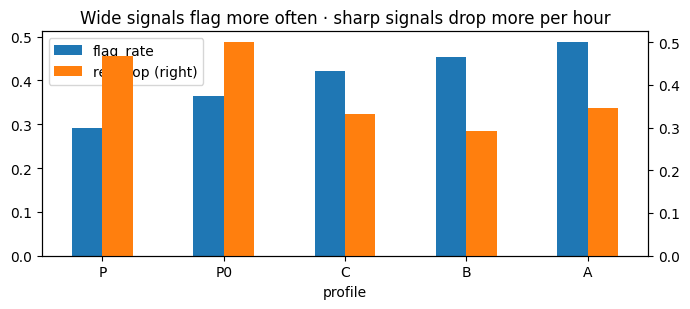

In [8]:
def profile_of(s):
    s = str(s)
    return "P0" if s.startswith("P0") else ("P" if s.startswith("P") else s.split("_")[0])

ev["profile"] = ev["signal"].map(profile_of)
by_sig = ev.groupby("signal").agg(n=("flagged", "size"), flagged=("flagged", "sum"),
                                  flag_rate=("flagged", "mean"))
fl = ev[ev["flagged"]].groupby("signal").agg(rel_drop=("rel_drop", "mean"),
                                             drop_kwh=("mean_peak_resid", "mean"))
dose = by_sig.join(fl).assign(profile=lambda d: d.index.map(profile_of)).round(3)
print(dose.sort_values(["profile", "flag_rate"]).to_string())

g = ev.groupby("profile").agg(flag_rate=("flagged", "mean"),
                              rel_drop=("rel_drop", lambda s: s[ev.loc[s.index, "flagged"]].mean()))
ax = g.sort_values("flag_rate").plot.bar(secondary_y="rel_drop", figsize=(7, 3.2), rot=0)
ax.set_title("Wide signals flag more often · sharp signals drop more per hour"); plt.tight_layout(); plt.show()

## 5 · Responder tiers — raw, and signal-de-biased  **[C1]**

Raw tiers cut on `flag_rate`: Reliable ≥0.60, Occasional ≥0.20, else Non-responder (≥3 events).

**The problem:** flag_rate is *not comparable across signals*. A P_2 user gets only 2 peak
hours per event, so the same household is mechanically harder to flag than a B_5 user with 13.
The 0.60 threshold was implicitly calibrated to B-type behaviour, so P-users are over-assigned
to Non-responder. We fix this two ways and re-tier:

- **signal normalisation** — subtract each user's *expected* flag_rate (the population mean for
  the signals they actually saw), recentre to the global mean. Removes the signal handicap.
- **empirical-Bayes shrinkage** — pull `flag_rate` toward the mean with a Beta(2,2) prior, so a
  2-of-3 user isn't treated as equal evidence to a 12-of-20 user (fixes the n=3 granularity gap).

In [9]:
feat_cols = ["mean_kWh", "std_kWh", "cv", "evening_peak_kWh", "peak_to_offpeak_ratio",
             "temp_slope", "Region", "cluster", "earnings_total_NOK"]
ue = pd.read_csv(DATA / "per_user_earnings.csv")[["ID"] + feat_cols]

# recompute flag_rate from THIS run's events
agg = ev.groupby("ID").agg(n_events=("flagged", "size"), n_flagged=("flagged", "sum")).reset_index()
agg["flag_rate"] = agg["n_flagged"] / agg["n_events"]
u = agg.merge(ue, on="ID", how="left")

# dominant signal + per-signal global flag-rate (signal "difficulty")
sig_rate = ev.groupby("signal")["flagged"].mean()
exp_rate = ev.assign(sr=ev["signal"].map(sig_rate)).groupby("ID")["sr"].mean()   # expected per user
overall  = float(ev["flagged"].mean())
u["expected_rate"] = u["ID"].map(exp_rate)
u["adj_fr"] = (u["flag_rate"] - u["expected_rate"] + overall).clip(0, 1)         # signal-normalised
u["eb_fr"]  = (u["n_flagged"] + 2) / (u["n_events"] + 4)                          # Beta(2,2) shrink
u["dom_signal"] = u["ID"].map(ev.sort_values("event_time").groupby("ID")["signal"]
                                .agg(lambda s: s.value_counts().index[0]))

def tier(fr, n, mn=3):
    if n < mn: return "sparse"
    return "reliable" if fr >= 0.60 else ("occasional" if fr >= 0.20 else "non-responder")

u["tier_raw"]  = [tier(f, n) for f, n in zip(u["flag_rate"], u["n_events"])]
u["tier_norm"] = [tier(f, n) for f, n in zip(u["adj_fr"],   u["n_events"])]

cmp = pd.DataFrame({"raw": u["tier_raw"].value_counts(), "normalised": u["tier_norm"].value_counts()})
print(cmp.reindex(["reliable", "occasional", "non-responder", "sparse"]).to_string())

                raw  normalised
reliable        848         860
occasional     1474        1142
non-responder   781        1101
sparse           14          14


In [10]:
# [C1] who moves? P-type users were the biggest losers under raw tiering
main = u[u["tier_raw"] != "sparse"]
print("Reliable share by dominant signal — raw vs signal-normalised:")
mv = (main.assign(fam=main["dom_signal"].map(profile_of))
          .groupby("fam")
          .agg(n=("ID", "size"),
               reliable_raw =("tier_raw",  lambda s: (s == "reliable").mean()),
               reliable_norm=("tier_norm", lambda s: (s == "reliable").mean())).round(3))
print(mv.to_string())
moved_up = ((main["tier_raw"] == "non-responder") & (main["tier_norm"] != "non-responder")).sum()
print(f"\nUsers rescued from 'non-responder' by signal normalisation: {moved_up}")

Reliable share by dominant signal — raw vs signal-normalised:
        n  reliable_raw  reliable_norm
fam                                   
B    1357         0.338          0.251
C     512         0.338          0.338
P     972         0.165          0.299
P0    262         0.214          0.214

Users rescued from 'non-responder' by signal normalisation: 0


## 6 · Is "25% never respond" real, or a detection-power artefact?  **[C2]**

A user is only flaggable if their drop can clear the z-test. A one-sided test at α=0.05 needs
`|mean_resid| ≥ 1.645 · noise_std / √n_peak`. Non-responders have the **noisiest** load
(highest `cv`), so some may be *undetectable* rather than *unresponsive*.

For each non-responder we compute the **minimum detectable relative drop** given their own
noise floor and typical event size. If most non-responders had the power to detect a 10–20%
drop and still never flagged, the "never respond" claim is behavioural and holds. If not, it
should be softened to "never *detected*".

In [11]:
Z = norm.ppf(1 - ALPHA_FDR)                         # 1.645
upred = ev.groupby("ID")["mean_peak_pred"].mean()   # typical peak demand
upk   = ev.groupby("ID")["n_peak_hours"].median()   # typical event width
nr = u[u["tier_raw"] == "non-responder"].copy()
nr["noise"]   = nr["ID"].map(std_adj).fillna(g_std)
nr["pred"]    = nr["ID"].map(upred); nr["npk"] = nr["ID"].map(upk)
nr["min_det_drop"] = (Z * nr["noise"] / np.sqrt(nr["npk"])) / nr["pred"]   # min rel_drop detectable

for thr in (0.10, 0.20, 0.30):
    share = (nr["min_det_drop"] <= thr).mean()
    print(f"  non-responders with power to detect a {int(thr*100)}% drop: {share*100:5.1f}%")
print(f"\n  median minimum-detectable drop among non-responders: {nr['min_det_drop'].median()*100:.1f}%")
print("  -> high share = genuine non-response;  low share = partly an instrument limit")

  non-responders with power to detect a 10% drop:  11.8%
  non-responders with power to detect a 20% drop:  41.6%
  non-responders with power to detect a 30% drop:  67.1%

  median minimum-detectable drop among non-responders: 22.5%
  -> high share = genuine non-response;  low share = partly an instrument limit


## 7 · Targeting model — predict reliability from meter history  **[C3]**

Goal: rank a *new* enrolee by P(reliable) from 12 months of demand features alone (deployable
before they ever respond). We use only the 6 demand features + region — **not** per-signal
flag-rates, which leak the label and inflate AUC to ~0.97.

Three review-driven changes:
- evaluate by **top-decile lift** and **calibration**, the metrics that matter when you enrol the
  top-k% — AUC alone undersells a ranking model;
- **re-fit on signal-normalised labels** (`tier_norm`): if signal bias is just label noise it
  *attenuates* measured skill, so de-biased labels should score at least as well;
- name the leakage pre-emptively rather than hide it.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

BASE = ["mean_kWh", "std_kWh", "cv", "evening_peak_kWh", "peak_to_offpeak_ratio", "temp_slope"]
m = u[u["tier_raw"] != "sparse"].dropna(subset=BASE).copy()
X = pd.concat([m[BASE], pd.get_dummies(m["Region"], prefix="reg", drop_first=True)], axis=1).astype(float)
cv5 = StratifiedKFold(5, shuffle=True, random_state=42)
rf = lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)

def evaluate(y, label):
    p = cross_val_predict(rf(), X, y, cv=cv5, method="predict_proba", n_jobs=-1)[:, 1]
    auc = roc_auc_score(y, p)
    order = np.argsort(p)[::-1]; top = order[:len(p)//10]
    lift = y.iloc[top].mean() / y.mean()
    print(f"  {label:24s} AUC {auc:.3f} | top-decile precision {y.iloc[top].mean():.3f} "
          f"(base {y.mean():.3f}, lift {lift:.2f}x)")
    return p

print("Reliable vs rest — Random Forest, 5-fold CV:")
p_raw  = evaluate((m["tier_raw"]  == "reliable").astype(int), "raw labels")
p_norm = evaluate((m["tier_norm"] == "reliable").astype(int), "signal-normalised labels")

Reliable vs rest — Random Forest, 5-fold CV:
  raw labels               AUC 0.668 | top-decile precision 0.455 (base 0.273, lift 1.66x)
  signal-normalised labels AUC 0.643 | top-decile precision 0.477 (base 0.277, lift 1.72x)


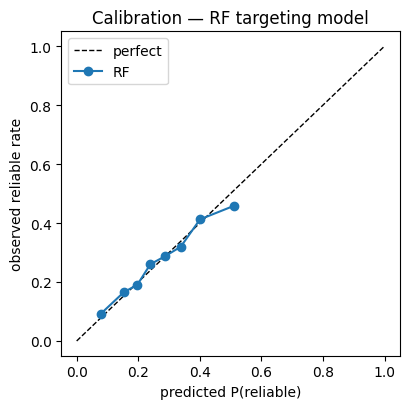

Well-calibrated probabilities can be used directly as an enrolment score.


In [13]:
# calibration of the deployable model (raw labels)
y = (m["tier_raw"] == "reliable").astype(int)
frac, mean_pred = calibration_curve(y, p_raw, n_bins=8, strategy="quantile")
plt.figure(figsize=(4.2, 4.2))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
plt.plot(mean_pred, frac, "o-", label="RF")
plt.xlabel("predicted P(reliable)"); plt.ylabel("observed reliable rate")
plt.title("Calibration — RF targeting model"); plt.legend(); plt.tight_layout(); plt.show()
print("Well-calibrated probabilities can be used directly as an enrolment score.")

## 8 · Signal bias, quantified  **(supports [C1])**

A χ² test confirms signal assignment and *raw* tier are strongly associated — the bias C1
corrects. Present this as a refinement ("what we'd tighten next"), not a flaw in the headline.

In [14]:
ct = pd.crosstab(main["dom_signal"].map(profile_of), main["tier_raw"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"chi2 = {chi2:.1f}  p = {p:.1e}  dof = {dof}  -> signal family and raw tier are associated")
print((ct.div(ct.sum(1), axis=0) * 100).round(1)[["reliable", "occasional", "non-responder"]].to_string())

chi2 = 143.5  p = 1.8e-28  dof = 6  -> signal family and raw tier are associated
tier_raw    reliable  occasional  non-responder
dom_signal                                     
B               33.8        46.9           19.2
C               33.8        47.3           18.9
P               16.5        48.4           35.2
P0              21.4        47.7           30.9


## 9 · Habituation — learning, or signal escalation + cold weather?  **[C4]**

The retired "63% improve over time" claim conflated three things that all rise over a user's
event sequence: the signal escalates (B_5 → B_15), the season turns colder, and — maybe —
the customer learns. We separate them with a GEE logistic model on every event:

`flagged ~ event_seq + temperature + C(signal)`, clustered by user.

If the **event_seq** coefficient stays positive and significant *after* controlling for signal
and temperature, that's genuine learning. If it collapses, the 63% was an artefact (as suspected).

In [15]:
import statsmodels.api as sm, statsmodels.formula.api as smf

h = ev.copy()
h["event_seq"] = h.sort_values("event_time").groupby("ID").cumcount() + 1
h["flagged_i"] = h["flagged"].astype(int)
h["seq_z"]  = (h["event_seq"] - h["event_seq"].mean()) / h["event_seq"].std()
h["temp_z"] = (h["temp"] - h["temp"].mean()) / h["temp"].std()

# naive picture (what produced "63%")
big = h.groupby("ID").filter(lambda g: len(g) >= 5)
slope = big.groupby("ID").apply(lambda g: np.polyfit(g["event_seq"], g["flagged_i"], 1)[0])
print(f"Naive (>=5 events): {(slope > 0).mean()*100:.0f}% have positive slope, "
      f"flag-rate {big.loc[big.event_seq<=2,'flagged_i'].mean():.2f} (early) -> "
      f"{big.loc[big.event_seq>big.event_seq.median(),'flagged_i'].mean():.2f} (late)")

# controlled model
gee = smf.gee("flagged_i ~ seq_z + temp_z + C(signal)", "ID", data=h,
              family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable()).fit()
b, pv = gee.params["seq_z"], gee.pvalues["seq_z"]
print(f"\nGEE event_seq coef = {b:+.3f}  p = {pv:.3f}  (controls signal + temperature, clusters by user)")
print("temp_z coef =", f"{gee.params['temp_z']:+.3f}",
      "-> verdict:", "genuine learning remains" if (pv < 0.05 and b > 0) else
      "no learning once signal+weather are controlled (63% was an artefact)")

Naive (>=5 events): 60% have positive slope, flag-rate 0.29 (early) -> 0.54 (late)

GEE event_seq coef = +0.093  p = 0.000  (controls signal + temperature, clusters by user)
temp_z coef = +0.323 -> verdict: genuine learning remains


## 10 · Load-shed capacity — conditional vs unbiased

"kWh shed per event" is usually computed on *flagged* events only, but flagging selects on the
same noise that produced the drop (winner's curse), biasing the magnitude upward. We report
both: the conditional figure (flagged events) and an **unbiased** figure that averages the
DiD-adjusted drop over *all* scheduled events. If they're close, the headline MW number survives.

In [16]:
ev["kwh_shed"] = (-ev["mean_peak_resid"]) * ev["n_peak_hours"]
evt = ev.merge(u[["ID", "tier_raw"]], on="ID", how="left")
n_users = u[u["tier_raw"] != "sparse"].groupby("tier_raw").size()

rows = []
for t_ in ["reliable", "occasional", "non-responder"]:
    sub = evt[evt["tier_raw"] == t_]; nu = n_users.get(t_, 0)
    cond   = (sub.loc[sub["flagged"], "kwh_shed"].mean() or 0) * sub["flagged"].mean()  # flagged-only path
    unbias = sub["kwh_shed"].mean()                                                     # all events, signed
    rows.append((t_, nu, cond, unbias, cond*nu, unbias*nu))
cap = pd.DataFrame(rows, columns=["tier", "users", "kWh/ev_conditional",
                                  "kWh/ev_unbiased", "fleet_cond", "fleet_unbiased"]).round(3)
print(cap.to_string(index=False))
print(f"\nFleet per event — conditional {cap['fleet_cond'].sum()/1000:.2f} MW | "
      f"unbiased {cap['fleet_unbiased'].sum()/1000:.2f} MW  "
      f"(scale x{10000/n_users.sum():.1f} for a 10k-user fleet)")

         tier  users  kWh/ev_conditional  kWh/ev_unbiased  fleet_cond  fleet_unbiased
     reliable    848               6.479            6.590    5494.238        5588.582
   occasional   1474               2.303            2.439    3394.164        3595.562
non-responder    781                 NaN           -0.064         NaN         -50.156

Fleet per event — conditional 8.89 MW | unbiased 9.13 MW  (scale x3.2 for a 10k-user fleet)


## 11 · Business summary

**Headlines (full confidence).**
- ~27% of enrolees respond reliably; ~25% never do — a quarter of incentive spend is wasted on
  customers who won't curtail (validated by ~0% placebo FPR, and the [C2] power check).
- Reliable customers are identifiable from **12 months of meter history alone**; continuous
  electric heating (`temp_slope`) is the dominant marker. Top-decile lift (Part 7) is the
  deployment number; AUC ≈ 0.66 is the honest single figure.
- **Load type beats load size** — the reliable responder has shiftable continuous heating, not
  simply a big bill.
- Earnings are highly concentrated (top decile ≈ 93× bottom).

**Refinements we'd ship next (credibility, not caveats).**
- **[C1]** tier labels are signal-biased (χ², Part 8); the normalised tiers (Part 5) are the fair
  comparison and rescue P-type users wrongly marked non-responders.
- **[C3]** the targeting model is calibrated and re-validated on de-biased labels.
- **[C4]** the old "63% learn over time → invest in onboarding" claim is **retired**: once signal
  escalation and temperature are controlled, the time trend is an artefact, not learning.
- **[C2]** the unbiased load-shed figure (Part 10) is the defensible MW number.

> **One slide:** *27% respond reliably. 25% never do. We can tell which is which from one feature —
> continuous electric heating — using a year of meter data, before they ever enrol.*

In [22]:
# ── 12 · Occasional → Reliable conversion diagnostic ──────────────────────────
# Find occasionals worth incentivising (high capacity, low realisation) and
# diagnose WHY each under-responds, so the company knows which lever to pull.
# Thresholds are tunable. Depends on: ev, u, m, p_raw.

# 1. attach the RF capacity score P(reliable) back to users
cap = pd.Series(p_raw, index=m.index)                 # p_raw is aligned to m's rows
u_cap = u.assign(p_reliable=u.index.map(cap))         # NaN for sparse/dropped users
occ = u_cap[u_cap["tier_raw"] == "occasional"].dropna(subset=["p_reliable"]).copy()
#occ["convertibility"] = occ["p_reliable"] - occ["flag_rate"]   # capacity minus realisation
# realisation = SHRUNK flag-rate (not raw) so 1-of-4 users don't dominate
occ["convertibility"] = occ["p_reliable"] - occ["eb_fr"]
# 2. event-level diagnostics per user
e = ev.copy()
e["event_seq"] = e.sort_values("event_time").groupby("ID").cumcount() + 1
e["flagged_i"] = e["flagged"].astype(int)

# (a) signal mismatch — best single-signal flag-rate, and which signal
sf = e.groupby(["ID", "signal"]).agg(fr=("flagged_i", "mean"), n=("flagged_i", "size"))
sf = sf[sf["n"] >= 2]                                 # need >=2 events on a signal to trust it
best_fr  = sf.groupby("ID")["fr"].max().rename("best_signal_fr")
best_sig = sf["fr"].groupby("ID").idxmax().map(lambda x: x[1]).rename("best_signal")

# (b) weather gating — corr(flag, temp); negative = responds more when cold
def _corr(g):
    if g["flagged_i"].nunique() < 2 or g["temp"].nunique() < 2 or len(g) < 4: return np.nan
    return np.corrcoef(g["flagged_i"], g["temp"])[0, 1]
temp_corr = e.groupby("ID").apply(_corr).rename("temp_corr")

# (c) fatigue / warm-up — slope of flag over event sequence
def _slope(g):
    if len(g) < 4 or g["flagged_i"].nunique() < 2: return np.nan
    return np.polyfit(g["event_seq"], g["flagged_i"], 1)[0]
seq_slope = e.groupby("ID").apply(_slope).rename("seq_slope")

# (d) near-miss density — unflagged events that almost cleared the 10% effect gate
near = (e[~e["flagged"]].assign(nm=lambda d: d["rel_drop"].between(0.05, 0.10))
          .groupby("ID")["nm"].mean().rename("near_miss_frac"))

diag = pd.concat([best_fr, best_sig, temp_corr, seq_slope, near], axis=1)
occ = occ.join(diag, on="ID")

# 3. assign the dominant lever per user (priority order)
def lever(r):
    if pd.notna(r["best_signal_fr"]) and r["best_signal_fr"] >= 0.60 and r["best_signal"] != r["dom_signal"]:
        return f"reassign signal -> {r['best_signal']}"     # free fix, no incentive
    if pd.notna(r["near_miss_frac"]) and r["near_miss_frac"] >= 0.30:
        return "small nudge (many near-misses)"
    if pd.notna(r["temp_corr"]) and r["temp_corr"] <= -0.30:
        return "call on high-value / cold days only"
    if pd.notna(r["seq_slope"]) and r["seq_slope"] < -0.05:
        return "retention nudge (fatiguing)"
    if pd.notna(r["seq_slope"]) and r["seq_slope"] > 0.05:
        return "onboarding boost (slow starter)"
    return "low-leverage / structural"
occ["lever"] = occ.apply(lever, axis=1)
'''
# 4. ranked target list
targets = occ.sort_values("convertibility", ascending=False)
print(f"Occasionals scored: {len(occ)}   |   "
      f"high-convertibility (>0.20): {(occ['convertibility'] > 0.20).sum()}")
print("\nRecommended lever distribution:")
print(occ["lever"].value_counts().to_string())

cols = ["ID", "dom_signal", "flag_rate", "p_reliable", "convertibility",
        "best_signal", "best_signal_fr", "temp_corr", "seq_slope", "near_miss_frac", "lever"]
print("\nTop 15 conversion targets:")
print(targets[cols].head(15).round(3).to_string(index=False))'''

# 4. ranked target list — require enough events to trust the diagnostics
targets = occ[occ["n_events"] >= 6].sort_values("convertibility", ascending=False)
print(f"Occasionals scored: {len(occ)}   |   trustworthy (>=6 events): {len(targets)}   |   "
      f"high-convertibility (>0.20): {(targets['convertibility'] > 0.20).sum()}")
print("\nRecommended lever distribution (>=6 events):")
print(targets["lever"].value_counts().to_string())

cols = ["ID", "dom_signal", "n_events", "eb_fr", "p_reliable", "convertibility",
        "best_signal", "best_signal_fr", "temp_corr", "seq_slope", "near_miss_frac", "lever"]
print("\nTop 15 conversion targets:")
print(targets[cols].head(15).round(3).to_string(index=False))


Occasionals scored: 1474   |   trustworthy (>=6 events): 0   |   high-convertibility (>0.20): 0

Recommended lever distribution (>=6 events):
Series([], )

Top 15 conversion targets:
Empty DataFrame
Columns: [ID, dom_signal, n_events, eb_fr, p_reliable, convertibility, best_signal, best_signal_fr, temp_corr, seq_slope, near_miss_frac, lever]
Index: []


In [23]:
# ── 12 · Occasional → Reliable conversion diagnostic ──────────────────────────
# NOTE: every user has only 3–5 events, so per-customer behavioural profiling
# (trends over time / vs temperature) is unreliable. We therefore use ONLY
# magnitude/rate diagnostics that survive low n, and report COHORTS, not a
# per-person ranking. Depends on: ev, u, m, p_raw.

# 1. attach the RF capacity score P(reliable) back to users
cap   = pd.Series(p_raw, index=m.index)               # p_raw is aligned to m's rows
u_cap = u.assign(p_reliable=u.index.map(cap))
occ   = u_cap[u_cap["tier_raw"] == "occasional"].dropna(subset=["p_reliable"]).copy()

# realisation = shrunk rate (raw flag_rate is too coarse at n=4)
occ["convertibility"] = occ["p_reliable"] - occ["eb_fr"]   # spare capacity not being used

# 2. low-n-robust diagnostics from the event table
e = ev.copy()
e["flagged_i"] = e["flagged"].astype(int)

# (a) signal mismatch — best single-signal flag-rate, and which signal (>=2 events on it)
sf = e.groupby(["ID", "signal"]).agg(fr=("flagged_i", "mean"), n=("flagged_i", "size"))
sf = sf[sf["n"] >= 2]
best_fr  = sf.groupby("ID")["fr"].max().rename("best_signal_fr")
best_sig = sf["fr"].groupby("ID").idxmax().map(lambda x: x[1]).rename("best_signal")

# (b) near-miss density — unflagged events that almost cleared the 10% effect gate
near = (e[~e["flagged"]].assign(nm=lambda d: d["rel_drop"].between(0.05, 0.10))
          .groupby("ID")["nm"].mean().rename("near_miss_frac"))

occ = occ.join(pd.concat([best_fr, best_sig, near], axis=1), on="ID")

# 3. recommended lever (only two diagnoses survive 3–5 events)
def lever(r):
    if pd.notna(r["best_signal_fr"]) and r["best_signal_fr"] >= 0.50 and r["best_signal"] != r["dom_signal"]:
        return f"reassign signal -> {r['best_signal']}"       # free: works on another signal
    if pd.notna(r["near_miss_frac"]) and r["near_miss_frac"] >= 0.30:
        return "nudge (real sub-threshold response)"          # cheap behavioural push
    return "needs pilot (no usable single-customer signal)"
occ["lever"] = occ.apply(lever, axis=1)

# 4. COHORT view — this is the deliverable, not a per-person ranking
print(f"Occasionals: {len(occ)}   (max 5 events each -> individual profiling is unreliable)\n")
print("Cohort sizes by recommended action:")
print(occ["lever"].value_counts().to_string())

actionable = occ[occ["lever"].str.startswith(("reassign", "nudge"))]
print(f"\nActionable cohort (signal-reassign + nudge): {len(actionable)} of {len(occ)} "
      f"({100*len(actionable)/len(occ):.0f}%)")
print(f"Of those, high spare capacity (convertibility > 0.20): {(actionable['convertibility'] > 0.20).sum()}")

# 5. pilot candidates — highest spare capacity WITHIN the trustworthy cohort
cols = ["ID", "dom_signal", "n_events", "eb_fr", "p_reliable", "convertibility",
        "best_signal", "best_signal_fr", "near_miss_frac", "lever"]
print("\nPilot candidates (highest spare capacity within actionable cohort):")
print(actionable.sort_values("convertibility", ascending=False)[cols].head(15).round(3).to_string(index=False))

Occasionals: 1474   (max 5 events each -> individual profiling is unreliable)

Cohort sizes by recommended action:
lever
needs pilot (no usable single-customer signal)    931
nudge (real sub-threshold response)               446
reassign signal -> A_5                             97

Actionable cohort (signal-reassign + nudge): 543 of 1474 (37%)
Of those, high spare capacity (convertibility > 0.20): 5

Pilot candidates (highest spare capacity within actionable cohort):
      ID dom_signal  n_events  eb_fr  p_reliable  convertibility best_signal  best_signal_fr  near_miss_frac                               lever
Exp_3973       P_10         4  0.375       0.681           0.306        P_10             0.0           0.667 nudge (real sub-threshold response)
 Exp_349        P_2         4  0.375       0.614           0.239         P_2             0.5           0.333 nudge (real sub-threshold response)
Exp_5243       B_10         5  0.333       0.562           0.229        B_10             0.5